# Objective 3 - Explainable AI for RFP to SKU Matching

This notebook turns the Objective 1 matching engine and the Objective 2 robustness experiments into a single explainability pipeline.

It answers three questions:

1. Why did an RFP and SKU fully match?
2. Why did they only partially match?
3. Why did they fail to match at all?

The pipeline uses the saved Objective 1 artifacts, summarizes Objective 2 experiment evidence, and writes human-readable reports to `OBJ3/results`.


In [1]:
from __future__ import annotations

import json
import re
import warnings
from pathlib import Path
from typing import Any, Dict, Iterable, List, Optional, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 160)

BASE_DIR = Path('/home/nikhil/Dev/MajorProject')
OBJ1_DIR = BASE_DIR / 'obj1_model_artifacts'
OBJ2_DIR = BASE_DIR / 'OBJ2'
OBJ3_DIR = BASE_DIR / 'OBJ3'
RESULTS_DIR = OBJ3_DIR / 'results'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print(f'Base directory  : {BASE_DIR}')
print(f'OBJ1 artifacts  : {OBJ1_DIR}')
print(f'OBJ2 experiments: {OBJ2_DIR}')
print(f'OBJ3 results    : {RESULTS_DIR}')

Base directory  : /home/nikhil/Dev/MajorProject
OBJ1 artifacts  : /home/nikhil/Dev/MajorProject/obj1_model_artifacts
OBJ2 experiments: /home/nikhil/Dev/MajorProject/OBJ2
OBJ3 results    : /home/nikhil/Dev/MajorProject/OBJ3/results


## 1. Load and prepare data

The pipeline starts from the saved Objective 1 artifacts. That keeps OBJ3 reproducible and avoids rerunning the full matching engine when we only need explanation logic.

In [2]:
def load_table(path: Path, *, kind: str = 'csv', fallback_path: Optional[Path] = None) -> Optional[pd.DataFrame]:
    if path.exists():
        try:
            if kind == 'csv':
                return pd.read_csv(path)
            if kind == 'parquet':
                return pd.read_parquet(path)
            raise ValueError(f'Unsupported kind: {kind}')
        except ImportError:
            print(f'⚠️ Parquet engine unavailable for {path}')
            if fallback_path is not None and fallback_path.exists():
                print(f'   Falling back to CSV: {fallback_path}')
                return pd.read_csv(fallback_path)
            return None
        except pd.errors.EmptyDataError:
            print(f'⚠️ Empty CSV: {path}')
            return None
    if fallback_path is not None and fallback_path.exists():
        return pd.read_csv(fallback_path)
    print(f'⚠️ Missing {kind.upper()}: {path}')
    return None


def clean_columns(frame: Optional[pd.DataFrame]) -> Optional[pd.DataFrame]:
    if frame is None:
        return None
    frame = frame.copy()
    frame.columns = frame.columns.astype(str).str.strip()
    return frame


DATA_DIR = BASE_DIR / 'datasets'

with open(OBJ1_DIR / 'model_config.json', 'r', encoding='utf-8') as handle:
    model_config = json.load(handle)

baseline_results = clean_columns(load_table(OBJ1_DIR / 'baseline_results.csv', kind='csv'))
match_df = clean_columns(load_table(OBJ1_DIR / 'match_df.parquet', kind='parquet'))
rfp_df = clean_columns(load_table(OBJ1_DIR / 'rfp_df_with_gt.parquet', kind='parquet', fallback_path=DATA_DIR / 'rfp_specs_7000.csv'))
product_df = clean_columns(load_table(OBJ1_DIR / 'product_df.parquet', kind='parquet', fallback_path=DATA_DIR / 'product_catalog.csv'))
rfp_embeddings = np.load(OBJ1_DIR / 'rfp_embeddings_mpnet.npy')
product_embeddings = np.load(OBJ1_DIR / 'product_embeddings_mpnet.npy')

if rfp_df is None or product_df is None:
    raise FileNotFoundError('OBJ3 requires the RFP and product tables from OBJ1 or the source CSVs in datasets/.')

for frame_name, frame in [('rfp_df', rfp_df), ('product_df', product_df)]:
    print(f'{frame_name:<12}: {frame.shape}')

if match_df is None:
    print('match_df     : will be reconstructed from the source tables')
else:
    print(f'match_df     : {match_df.shape}')

print('\nModel config keys:', sorted(model_config.keys()))
print('Baseline rows    :', 0 if baseline_results is None else len(baseline_results))
print('RFP embeddings   :', rfp_embeddings.shape)
print('Product embeddings:', product_embeddings.shape)

⚠️ Missing PARQUET: /home/nikhil/Dev/MajorProject/obj1_model_artifacts/match_df.parquet
⚠️ Parquet engine unavailable for /home/nikhil/Dev/MajorProject/obj1_model_artifacts/rfp_df_with_gt.parquet
   Falling back to CSV: /home/nikhil/Dev/MajorProject/datasets/rfp_specs_7000.csv
⚠️ Parquet engine unavailable for /home/nikhil/Dev/MajorProject/obj1_model_artifacts/product_df.parquet
   Falling back to CSV: /home/nikhil/Dev/MajorProject/datasets/product_catalog.csv
rfp_df      : (7000, 17)
product_df  : (200, 16)
match_df     : will be reconstructed from the source tables

Model config keys: ['K', 'baseline_metrics', 'exact_fields', 'hybrid_weights', 'mandatory_weight', 'numeric_fields', 'product_text_col', 'rfp_text_col', 'sbert_model', 'standards_match']
Baseline rows    : 7
RFP embeddings   : (7000, 768)
Product embeddings: (200, 768)


## 2. Import matching logic from Objective 1

Objective 1 already gives the scoring signals we need for explainability: structured score, semantic score, standards score, and final compliance score. OBJ3 interprets those scores instead of recomputing the whole matcher.

In [8]:
EXACT_FIELDS = model_config.get('exact_fields', [])
NUMERIC_FIELDS = model_config.get('numeric_fields', {})
HYBRID_WEIGHTS = model_config.get('hybrid_weights', {'structured': 0.5, 'semantic': 0.3, 'standards': 0.2})
K_NEIGHBORS = int(model_config.get('K', 5))


def normalize_text(value: Any) -> str:
    if pd.isna(value):
        return ''
    return str(value).strip().lower()


SIZE_LADDER = [
    0.5, 0.75, 1.0, 1.5, 2.5, 4.0, 6.0, 10.0, 16.0,
    25.0, 35.0, 50.0, 70.0, 95.0, 120.0, 150.0, 185.0,
    240.0, 300.0, 400.0, 500.0, 630.0, 800.0, 1000.0,
]
SIZE_SET = set(SIZE_LADDER)


def adjacent_sizes(value: float) -> set[float]:
    if value not in SIZE_SET:
        value = min(SIZE_LADDER, key=lambda candidate: abs(candidate - value))
    index = SIZE_LADDER.index(value)
    neighbours = {value}
    if index > 0:
        neighbours.add(SIZE_LADDER[index - 1])
    if index < len(SIZE_LADDER) - 1:
        neighbours.add(SIZE_LADDER[index + 1])
    return neighbours


print('Exact fields   :', EXACT_FIELDS)
print('Numeric fields :', NUMERIC_FIELDS)
print('Hybrid weights :', HYBRID_WEIGHTS)
print('Top-K          :', K_NEIGHBORS)

Exact fields   : ['voltage_rating', 'conductor_material', 'insulation_type', 'sheath_type', 'temperature_rating', 'fire_resistance', 'armouring']
Numeric fields : {'core_count': 'exact', 'size_sqmm': 'ladder_adjacent'}
Hybrid weights : {'structured': 0.5, 'semantic': 0.3, 'standards': 0.2}
Top-K          : 5


## 3. Integrate Objective 2 experiments

Objective 2 contributes the robustness evidence. Where CSV outputs exist, the notebook will load them; where only the notebook exists, it will record the experiment as notebook-only so the pipeline stays honest about source coverage.

In [3]:
OBJ2_SOURCES = [
    ('Exp 1 - Numeric sensitivity', 'numeric_sensitivity', OBJ2_DIR / 'EXP1' / 'results' / 'exp1_ir_metrics_clean_vs_pert.csv'),
    ('Exp 1 - Numeric sensitivity summary', 'numeric_sensitivity', OBJ2_DIR / 'EXP1' / 'results' / 'exp1_numeric_accuracy_summary.csv'),
    ('Exp 1 - Per-RFP analysis', 'numeric_sensitivity', OBJ2_DIR / 'EXP1' / 'results' / 'exp1_per_rfp_analysis.csv'),
    ('Exp 2 - Unit variation', 'unit_variation', OBJ2_DIR / 'EXP2' / 'results' / 'exp2_ir_metrics_clean_vs_unit.csv'),
    ('Exp 2 - Per-RFP UES', 'unit_variation', OBJ2_DIR / 'EXP2' / 'results' / 'exp2_per_rfp_ues.csv'),
    ('Exp 2 - Per-transform UES', 'unit_variation', OBJ2_DIR / 'EXP2' / 'results' / 'exp2_per_transform_ues.csv'),
    ('Exp 2 - UES summary', 'unit_variation', OBJ2_DIR / 'EXP2' / 'results' / 'exp2_ues_summary.csv'),
    ('Exp 5 - Long document bias', 'long_doc_bias', OBJ2_DIR / 'EXP5' / 'RESULTS' / 'exp5_length_stratified.csv'),
    ('Exp 5 - Per-RFP metadata', 'long_doc_bias', OBJ2_DIR / 'EXP5' / 'RESULTS' / 'exp5_per_rfp_metadata.csv'),
    ('Exp 5 - Position analysis', 'long_doc_bias', OBJ2_DIR / 'EXP5' / 'RESULTS' / 'exp5_position_analysis.csv'),
    ('Exp 6 - Completeness metrics', 'partial_specs', OBJ2_DIR / 'EXP6' / 'RESULTS' / 'exp6_completeness_metrics.csv'),
    ('Exp 6 - Partial specs all levels', 'partial_specs', OBJ2_DIR / 'EXP6' / 'RESULTS' / 'exp6_partial_specs_all_levels.csv'),
    ('Exp 6 - Single token analysis', 'partial_specs', OBJ2_DIR / 'EXP6' / 'RESULTS' / 'exp6_single_token_analysis.csv'),
    ('Exp 7 - Field detection', 'positional_bias', OBJ2_DIR / 'EXP7' / 'RESULTS' / 'exp7_field_detection.csv'),
    ('Exp 7 - IR metrics by position', 'positional_bias', OBJ2_DIR / 'EXP7' / 'RESULTS' / 'exp7_ir_metrics_by_position.csv'),
    ('Exp 7 - Per-RFP stability', 'positional_bias', OBJ2_DIR / 'EXP7' / 'RESULTS' / 'exp7_per_rfp_stability.csv'),
    ('Exp 7 - Score stability', 'positional_bias', OBJ2_DIR / 'EXP7' / 'RESULTS' / 'exp7_score_stability.csv'),
]


EXPERIMENT_NOTEBOOK_ONLY = [
    ('Exp 3 - Missing parameters', 'missing_params', OBJ2_DIR / 'EXP3' / 'EXP3_MISSING_PARAMS.ipynb'),
    ('Exp 4 - Noise injection', 'noise_injection', OBJ2_DIR / 'EXP4' / 'EXP4_NOISE_INJECTION.ipynb'),
]


obj2_loaded_tables: List[pd.DataFrame] = []
obj2_inventory_rows: List[Dict[str, Any]] = []

for title, theme, path in OBJ2_SOURCES:
    table = load_table(path, kind='csv')
    obj2_inventory_rows.append({
        'title': title,
        'theme': theme,
        'path': str(path),
        'status': 'loaded' if table is not None else 'missing',
        'rows': None if table is None else len(table),
        'columns': None if table is None else len(table.columns),
    })
    if table is not None:
        table = clean_columns(table)
        table['source_title'] = title
        table['theme'] = theme
        obj2_loaded_tables.append(table)

obj2_inventory = pd.DataFrame(obj2_inventory_rows)
obj2_merged_summary = pd.concat(obj2_loaded_tables, ignore_index=True, sort=False) if obj2_loaded_tables else pd.DataFrame()
obj2_notebook_only = pd.DataFrame([
    {
        'title': title,
        'theme': theme,
        'notebook_path': str(path),
        'status': 'notebook_only',
    }
    for title, theme, path in EXPERIMENT_NOTEBOOK_ONLY
])

print('OBJ2 sources checked:')
display(obj2_inventory)
print('\nNotebook-only experiments:')
display(obj2_notebook_only)
print('\nMerged Obj2 summary shape:', obj2_merged_summary.shape)

if not obj2_merged_summary.empty:
    theme_counts = obj2_merged_summary.groupby('theme').size().sort_values(ascending=False)
    print('\nRows by theme:')
    display(theme_counts.to_frame('rows'))

⚠️ Empty CSV: /home/nikhil/Dev/MajorProject/OBJ2/EXP1/results/exp1_per_rfp_analysis.csv
⚠️ Empty CSV: /home/nikhil/Dev/MajorProject/OBJ2/EXP2/results/exp2_per_rfp_ues.csv
OBJ2 sources checked:


,title,theme,path,status,rows,columns
0,Exp 1 - Numeric sensitivity,numeric_sensitivity,/home/nikhil/Dev/MajorProject/OBJ2/EXP1/result...,loaded,7.0,13.0
1,Exp 1 - Numeric sensitivity summary,numeric_sensitivity,/home/nikhil/Dev/MajorProject/OBJ2/EXP1/result...,loaded,6.0,10.0
2,Exp 1 - Per-RFP analysis,numeric_sensitivity,/home/nikhil/Dev/MajorProject/OBJ2/EXP1/result...,missing,NaN,NaN
3,Exp 2 - Unit variation,unit_variation,/home/nikhil/Dev/MajorProject/OBJ2/EXP2/result...,loaded,7.0,13.0
4,Exp 2 - Per-RFP UES,unit_variation,/home/nikhil/Dev/MajorProject/OBJ2/EXP2/result...,missing,NaN,NaN
5,Exp 2 - Per-transform UES,unit_variation,/home/nikhil/Dev/MajorProject/OBJ2/EXP2/result...,loaded,6.0,6.0
6,Exp 2 - UES summary,unit_variation,/home/nikhil/Dev/MajorProject/OBJ2/EXP2/result...,loaded,6.0,6.0
7,Exp 5 - Long document bias,long_doc_bias,/home/nikhil/Dev/MajorProject/OBJ2/EXP5/RESULT...,loaded,7.0,17.0
8,Exp 5 - Per-RFP metadata,long_doc_bias,/home/nikhil/Dev/MajorProject/OBJ2/EXP5/RESULT...,loaded,7000.0,4.0
9,Exp 5 - Position analysis,long_doc_bias,/home/nikhil/Dev/MajorProject/OBJ2/EXP5/RESULT...,loaded,21.0,6.0



Notebook-only experiments:


,title,theme,notebook_path,status
0,Exp 3 - Missing parameters,missing_params,/home/nikhil/Dev/MajorProject/OBJ2/EXP3/EXP3_M...,notebook_only
1,Exp 4 - Noise injection,noise_injection,/home/nikhil/Dev/MajorProject/OBJ2/EXP4/EXP4_N...,notebook_only



Merged Obj2 summary shape: (56094, 141)

Rows by theme:


,rows
theme,
positional_bias,42019
long_doc_bias,7028
partial_specs,7015
unit_variation,19
numeric_sensitivity,13


## 4. Explainability rules

The explanation layer turns score components into language a reviewer can read:

- matching: the pair is strong across structured, semantic, and standards signals
- partially matching: some signals agree, but at least one major signal is weak or missing
- not matching: the pair lacks enough evidence across the three score channels


In [5]:
def split_terms(value: Any) -> List[str]:
    if pd.isna(value):
        return []
    text = normalize_text(value)
    parts = [part.strip() for part in re.split(r'[;,/|]+', text) if part.strip()]
    return parts if parts else ([text] if text else [])


def standards_match(rfp_standard: Any, sku_standard: Any) -> bool:
    left = normalize_text(rfp_standard)
    right = normalize_text(sku_standard)
    if not left or not right:
        return False
    return left in right or right in left


def compare_structured_fields(rfp_row: pd.Series, sku_row: pd.Series) -> Dict[str, Any]:
    exact_hits: List[str] = []
    exact_misses: List[str] = []
    numeric_hits: List[str] = []
    numeric_misses: List[str] = []
    evidence: List[str] = []

    for field in EXACT_FIELDS:
        rfp_value = normalize_text(rfp_row.get(field, ''))
        sku_value = normalize_text(sku_row.get(field, ''))
        if rfp_value and sku_value and rfp_value == sku_value:
            exact_hits.append(field)
        else:
            exact_misses.append(field)

    core_count_field = 'core_count'
    if core_count_field in NUMERIC_FIELDS:
        try:
            rfp_core = int(float(rfp_row.get(core_count_field)))
            sku_core = int(float(sku_row.get(core_count_field)))
            if rfp_core == sku_core:
                numeric_hits.append(core_count_field)
            else:
                numeric_misses.append(core_count_field)
        except Exception:
            numeric_misses.append(core_count_field)

    size_field = 'size_sqmm'
    if size_field in NUMERIC_FIELDS:
        try:
            rfp_size = float(rfp_row.get(size_field))
            sku_size = float(sku_row.get(size_field))
            if sku_size in adjacent_sizes(rfp_size):
                numeric_hits.append(size_field)
            else:
                numeric_misses.append(size_field)
        except Exception:
            numeric_misses.append(size_field)

    standards_required = rfp_row.get('standards_required', '')
    standards_complied = sku_row.get('standards_complied', '')
    standards_ok = standards_match(standards_required, standards_complied)

    if exact_hits:
        evidence.append(f"Exact field matches: {', '.join(exact_hits)}")
    if exact_misses:
        evidence.append(f"Exact field mismatches: {', '.join(exact_misses)}")
    if numeric_hits:
        evidence.append(f"Numeric agreements: {', '.join(numeric_hits)}")
    if numeric_misses:
        evidence.append(f"Numeric disagreements: {', '.join(numeric_misses)}")
    evidence.append('Standards overlap: yes' if standards_ok else 'Standards overlap: no')

    field_agreement_count = len(exact_hits) + len(numeric_hits) + int(standards_ok)
    field_total_count = len(EXACT_FIELDS) + len([field for field in NUMERIC_FIELDS if field in {'core_count', 'size_sqmm'}]) + 1

    return {
        'exact_hits': exact_hits,
        'exact_misses': exact_misses,
        'numeric_hits': numeric_hits,
        'numeric_misses': numeric_misses,
        'standards_ok': standards_ok,
        'field_agreement_count': field_agreement_count,
        'field_total_count': field_total_count,
        'evidence': evidence,
    }


def classify_pair(row: pd.Series) -> str:
    final_score = float(row.get('Final_Compliance_Score', 0.0))
    structured_score = float(row.get('Structured_Score', 0.0))
    semantic_score = float(row.get('Semantic_Score', 0.0))
    standards_score = float(row.get('Standards_Score', 0.0))

    strong_signals = sum([
        structured_score >= 0.65,
        semantic_score >= 0.60,
        standards_score >= 0.50,
    ])

    if final_score >= 0.72 and strong_signals >= 2:
        return 'matching'
    if final_score >= 0.42 or strong_signals >= 1:
        return 'partially matching'
    return 'not matching'


print('Explainability helpers defined.')

Explainability helpers defined.


In [6]:
def structured_score_from_rows(rfp_row: Dict[str, Any], sku_row: Dict[str, Any]) -> float:
    exact_fields = model_config.get('exact_fields', [])
    size_ladder = [
        0.5, 0.75, 1.0, 1.5, 2.5, 4.0, 6.0, 10.0, 16.0,
        25.0, 35.0, 50.0, 70.0, 95.0, 120.0, 150.0, 185.0,
        240.0, 300.0, 400.0, 500.0, 630.0, 800.0, 1000.0,
    ]
    size_set = set(size_ladder)

    def _normalize(value: Any) -> str:
        if pd.isna(value):
            return ''
        return str(value).strip().lower()

    def _adjacent_sizes(value: float) -> set[float]:
        if value not in size_set:
            value = min(size_ladder, key=lambda candidate: abs(candidate - value))
        index = size_ladder.index(value)
        neighbours = {value}
        if index > 0:
            neighbours.add(size_ladder[index - 1])
        if index < len(size_ladder) - 1:
            neighbours.add(size_ladder[index + 1])
        return neighbours

    mandatory_raw = str(rfp_row.get('mandatory_specs', ''))
    mandatory = set(field.strip() for field in mandatory_raw.split(';') if field.strip())

    score = 0.0
    total = 0.0

    for field in exact_fields:
        weight = 2.0 if field in mandatory else 1.0
        total += weight
        if _normalize(rfp_row.get(field, '')) == _normalize(sku_row.get(field, '')):
            score += weight

    core_weight = 2.0 if 'core_count' in mandatory else 1.0
    total += core_weight
    try:
        if int(float(rfp_row.get('core_count'))) == int(float(sku_row.get('core_count'))):
            score += core_weight
    except (TypeError, ValueError):
        pass

    size_weight = 2.0 if 'size_sqmm' in mandatory else 1.0
    total += size_weight
    try:
        rfp_size = float(rfp_row.get('size_sqmm'))
        sku_size = float(sku_row.get('size_sqmm'))
        if sku_size in _adjacent_sizes(rfp_size):
            score += size_weight
    except (TypeError, ValueError):
        pass

    return score / total if total > 0 else 0.0


def standards_score_from_rows(rfp_row: Dict[str, Any], sku_row: Dict[str, Any]) -> float:
    def _normalize(value: Any) -> str:
        if pd.isna(value):
            return ''
        return str(value).strip().lower()

    rfp_std = _normalize(rfp_row.get('standards_required', ''))
    sku_std = _normalize(sku_row.get('standards_complied', ''))

    if not rfp_std:
        return 0.0

    if rfp_std in sku_std or sku_std in rfp_std:
        return 1.0
    return 0.0


def rebuild_top1_match_df() -> pd.DataFrame:
    rfp_records = rfp_df.reset_index(drop=True).to_dict(orient='records')
    product_records = product_df.reset_index(drop=True).to_dict(orient='records')
    semantic_matrix = (rfp_embeddings @ product_embeddings.T).astype(np.float32)

    top_rows: List[Dict[str, Any]] = []
    for rfp_index, rfp_row in enumerate(rfp_records):
        best_sku_row: Optional[Dict[str, Any]] = None
        best_structured = 0.0
        best_semantic = -1.0
        best_standards = 0.0
        best_final = -1.0

        semantic_row = semantic_matrix[rfp_index]
        for sku_index, sku_row in enumerate(product_records):
            structured = structured_score_from_rows(rfp_row, sku_row)
            semantic = float(semantic_row[sku_index])
            standards = standards_score_from_rows(rfp_row, sku_row)
            final_score = 0.5 * structured + 0.3 * semantic + 0.2 * standards

            if final_score > best_final:
                best_final = final_score
                best_structured = structured
                best_semantic = semantic
                best_standards = standards
                best_sku_row = sku_row

        if best_sku_row is None:
            continue

        top_rows.append({
            'RFP_ID': rfp_row.get('rfp_id'),
            'SKU_ID': best_sku_row.get('sku_id'),
            'Structured_Score': best_structured,
            'Semantic_Score': best_semantic,
            'Standards_Score': best_standards,
            'Final_Compliance_Score': best_final,
        })

    return pd.DataFrame(top_rows)


if match_df is None:
    print('Reconstructing top-1 match table from the source CSVs and saved embeddings...')
    match_df = rebuild_top1_match_df()
    print(f'Reconstructed match_df: {match_df.shape}')
    display(match_df.head(10))
else:
    print('match_df already available; reconstruction skipped.')

Reconstructing top-1 match table from the source CSVs and saved embeddings...
Reconstructed match_df: (7000, 6)


,RFP_ID,SKU_ID,Structured_Score,Semantic_Score,Standards_Score,Final_Compliance_Score
0,RFP_0001,SKU_269,0.666667,0.588357,1.0,0.709840
1,RFP_0002,SKU_277,0.833333,0.587865,0.0,0.593026
2,RFP_0003,SKU_270,0.833333,0.500525,1.0,0.766824
3,RFP_0004,SKU_125,0.700000,0.655747,1.0,0.746724
4,RFP_0005,SKU_206,0.666667,0.554856,1.0,0.699790
5,RFP_0006,SKU_111,0.818182,0.346406,1.0,0.713013
6,RFP_0007,SKU_246,0.916667,0.656922,0.0,0.655410
7,RFP_0008,SKU_257,0.700000,0.607108,1.0,0.732133
8,RFP_0009,SKU_163,0.800000,0.476777,1.0,0.743033
9,RFP_0010,SKU_233,0.800000,0.641535,1.0,0.792461


## 5. Generate explainability reports

This section produces the user-facing output: one summary row per RFP, plus a compact reason object for the best SKU choice.

In [4]:
def build_pair_explanation(row: pd.Series) -> Dict[str, Any]:
    rfp_id = row['RFP_ID']
    sku_id = row['SKU_ID']

    rfp_row = rfp_df.loc[rfp_df['rfp_id'] == rfp_id].iloc[0]
    sku_row = product_df.loc[product_df['sku_id'] == sku_id].iloc[0]

    structure = compare_structured_fields(rfp_row, sku_row)
    category = classify_pair(row)
    ground_truth_sku = rfp_row.get('ground_truth_sku')
    is_ground_truth = pd.notna(ground_truth_sku) and str(ground_truth_sku) == str(sku_id)

    score_gap = float(row.get('Final_Compliance_Score', 0.0)) - float(row.get('Structured_Score', 0.0))
    evidence = structure['evidence'][:]
    if row.get('Semantic_Score', 0.0) >= 0.6:
        evidence.append('Semantic similarity is strong.')
    elif row.get('Semantic_Score', 0.0) >= 0.35:
        evidence.append('Semantic similarity is moderate.')
    else:
        evidence.append('Semantic similarity is weak.')

    if row.get('Standards_Score', 0.0) >= 0.5:
        evidence.append('Standards overlap supports the match.')
    elif structure['standards_ok']:
        evidence.append('Standards text overlaps even if the aggregate standards score is moderate.')
    else:
        evidence.append('No meaningful standards overlap was found.')

    if category == 'matching':
        decision = 'The pair is a strong match because the structured, semantic, and standards signals all support the same SKU.'
    elif category == 'partially matching':
        decision = 'The pair is a partial match because at least one important signal is present, but one or more signals are not strong enough for a full match.'
    else:
        decision = 'The pair is not a match because the overall evidence is too weak across the three score channels.'

    reason_object = {
        'rfp_id': rfp_id,
        'sku_id': sku_id,
        'category': category,
        'is_ground_truth': bool(is_ground_truth),
        'top_ranked': bool(row.get('rank', 0) == 1),
        'final_score': float(row.get('Final_Compliance_Score', 0.0)),
        'structured_score': float(row.get('Structured_Score', 0.0)),
        'semantic_score': float(row.get('Semantic_Score', 0.0)),
        'standards_score': float(row.get('Standards_Score', 0.0)),
        'structured_agreements': structure['exact_hits'] + structure['numeric_hits'],
        'structured_gaps': structure['exact_misses'] + structure['numeric_misses'],
        'decision': decision,
        'evidence': evidence,
    }

    explanation_text = (
        f"{decision} "
        f"Structured={row.get('Structured_Score', 0.0):.3f}, "
        f"Semantic={row.get('Semantic_Score', 0.0):.3f}, "
        f"Standards={row.get('Standards_Score', 0.0):.3f}, "
        f"Final={row.get('Final_Compliance_Score', 0.0):.3f}."
    )

    return {
        'rfp_id': rfp_id,
        'sku_id': sku_id,
        'rfp_name': rfp_row.get('spec_text_raw', '')[:180],
        'sku_name': sku_row.get('product_name', ''),
        'ground_truth_sku': ground_truth_sku,
        'category': category,
        'is_ground_truth': bool(is_ground_truth),
        'final_score': float(row.get('Final_Compliance_Score', 0.0)),
        'structured_score': float(row.get('Structured_Score', 0.0)),
        'semantic_score': float(row.get('Semantic_Score', 0.0)),
        'standards_score': float(row.get('Standards_Score', 0.0)),
        'score_gap': score_gap,
        'explanation_text': explanation_text,
        'reason_object': reason_object,
    }


best_match_df = (
    match_df
    .sort_values(['RFP_ID', 'Final_Compliance_Score'], ascending=[True, False])
    .assign(rank=lambda frame: frame.groupby('RFP_ID').cumcount() + 1)
)

best_match_rows = best_match_df.groupby('RFP_ID', as_index=False).head(1).copy()
best_match_rows['rank'] = 1

explanation_rows = [build_pair_explanation(row) for _, row in best_match_rows.iterrows()]
explanation_df = pd.DataFrame(explanation_rows)
explanation_df['best_match_label'] = explanation_df['category']

explanation_df.to_csv(RESULTS_DIR / 'obj3_top1_explanations.csv', index=False)
explanation_df[['rfp_id', 'sku_id', 'category', 'final_score', 'structured_score', 'semantic_score', 'standards_score']].to_csv(
    RESULTS_DIR / 'obj3_top1_summary.csv', index=False
)

print('Top-1 explanation rows:', explanation_df.shape)
display(explanation_df.head(10))

print('\nSaved reports:')
print(RESULTS_DIR / 'obj3_top1_explanations.csv')
print(RESULTS_DIR / 'obj3_top1_summary.csv')

AttributeError: 'NoneType' object has no attribute 'sort_values'

## 4. SHAP explainability

The explanation layer turns the top-1 score components into SHAP-style attributions a reviewer can read:

- matching: the pair sits above the baseline with positive SHAP contributions across the score channels
- partially matching: some signals support the match, but the SHAP contributions are mixed
- not matching: the score stays below the matching range and SHAP contributions remain weak

In [ ]:
def summarize_obj2_theme(frame: pd.DataFrame) -> pd.DataFrame:
    if frame.empty:
        return pd.DataFrame(columns=['theme', 'source_title', 'rows', 'metric_columns'])
    rows = []
    for (theme, source_title), group in frame.groupby(['theme', 'source_title'], dropna=False):
        numeric_cols = group.select_dtypes(include=[np.number]).columns.tolist()
        rows.append({
            'theme': theme,
            'source_title': source_title,
            'rows': len(group),
            'metric_columns': ', '.join(numeric_cols[:8]),
        })
    return pd.DataFrame(rows).sort_values(['theme', 'source_title']).reset_index(drop=True)


obj2_theme_summary = summarize_obj2_theme(obj2_merged_summary)
obj2_theme_summary.to_csv(RESULTS_DIR / 'obj3_obj2_theme_summary.csv', index=False)

print('Obj2 theme summary:')
display(obj2_theme_summary)

summary_path = RESULTS_DIR / 'obj3_obj2_theme_summary.csv'
print(f'Saved theme summary to {summary_path}')

if not obj2_notebook_only.empty:
    print('\nNotebook-only sources that still need result export:')
    display(obj2_notebook_only)

Obj2 theme summary:


,theme,source_title,rows,metric_columns
0,long_doc_bias,Exp 5 - Long document bias,7,"Top-1 (Clean), Top-1 (Pert), Δ Top-1, Top-5 (C..."
1,long_doc_bias,Exp 5 - Per-RFP metadata,7000,"Top-1 (Clean), Top-1 (Pert), Δ Top-1, Top-5 (C..."
2,long_doc_bias,Exp 5 - Position analysis,21,"Top-1 (Clean), Top-1 (Pert), Δ Top-1, Top-5 (C..."
3,numeric_sensitivity,Exp 1 - Numeric sensitivity,7,"Top-1 (Clean), Top-1 (Pert), Δ Top-1, Top-5 (C..."
4,numeric_sensitivity,Exp 1 - Numeric sensitivity summary,6,"Top-1 (Clean), Top-1 (Pert), Δ Top-1, Top-5 (C..."
5,partial_specs,Exp 6 - Completeness metrics,7,"Top-1 (Clean), Top-1 (Pert), Δ Top-1, Top-5 (C..."
6,partial_specs,Exp 6 - Partial specs all levels,7000,"Top-1 (Clean), Top-1 (Pert), Δ Top-1, Top-5 (C..."
7,partial_specs,Exp 6 - Single token analysis,8,"Top-1 (Clean), Top-1 (Pert), Δ Top-1, Top-5 (C..."
8,positional_bias,Exp 7 - Field detection,6,"Top-1 (Clean), Top-1 (Pert), Δ Top-1, Top-5 (C..."
9,positional_bias,Exp 7 - IR metrics by position,7,"Top-1 (Clean), Top-1 (Pert), Δ Top-1, Top-5 (C..."


Saved theme summary to /home/nikhil/Dev/MajorProject/OBJ3/results/obj3_obj2_theme_summary.csv

Notebook-only sources that still need result export:


,title,theme,notebook_path,status
0,Exp 3 - Missing parameters,missing_params,/home/nikhil/Dev/MajorProject/OBJ2/EXP3/EXP3_M...,notebook_only
1,Exp 4 - Noise injection,noise_injection,/home/nikhil/Dev/MajorProject/OBJ2/EXP4/EXP4_N...,notebook_only


## 7. Match classification visualization

These views help review how often the system lands in each explainability bucket and how strong the component scores are for the winning SKU.

Top-1 explanation rows: (7000, 21)


,rfp_id,sku_id,rfp_name,sku_name,ground_truth_sku,category,is_ground_truth,top_ranked,final_score,structured_score,semantic_score,standards_score,baseline_score,shap_structured,shap_semantic,shap_standards,score_gap,dominant_feature,explanation_text,reason_object,best_match_label
0,RFP_0001,SKU_269,,,None,partially matching,False,True,0.709840,0.666667,0.588357,1.0,0.669141,-0.011809,-0.007492,0.06,0.040699,Standards score,The pair is a partial match because the SHAP c...,"{'rfp_id': 'RFP_0001', 'sku_id': 'SKU_269', 'c...",partially matching
1,RFP_0002,SKU_277,,,None,partially matching,False,True,0.593026,0.833333,0.587865,0.0,0.669141,0.071524,-0.007639,-0.14,-0.076115,Standards score,The pair is a partial match because the SHAP c...,"{'rfp_id': 'RFP_0002', 'sku_id': 'SKU_277', 'c...",partially matching
2,RFP_0003,SKU_270,,,None,matching,False,True,0.766824,0.833333,0.500525,1.0,0.669141,0.071524,-0.033841,0.06,0.097683,Structured score,The pair is a strong match because the SHAP at...,"{'rfp_id': 'RFP_0003', 'sku_id': 'SKU_270', 'c...",matching
3,RFP_0004,SKU_125,,,None,matching,False,True,0.746724,0.700000,0.655747,1.0,0.669141,0.004858,0.012725,0.06,0.077583,Standards score,The pair is a strong match because the SHAP at...,"{'rfp_id': 'RFP_0004', 'sku_id': 'SKU_125', 'c...",matching
4,RFP_0005,SKU_206,,,None,partially matching,False,True,0.699790,0.666667,0.554856,1.0,0.669141,-0.011809,-0.017542,0.06,0.030649,Standards score,The pair is a partial match because the SHAP c...,"{'rfp_id': 'RFP_0005', 'sku_id': 'SKU_206', 'c...",partially matching
5,RFP_0006,SKU_111,,,None,partially matching,False,True,0.713013,0.818182,0.346406,1.0,0.669141,0.063949,-0.080077,0.06,0.043872,Semantic score,The pair is a partial match because the SHAP c...,"{'rfp_id': 'RFP_0006', 'sku_id': 'SKU_111', 'c...",partially matching
6,RFP_0007,SKU_246,,,None,partially matching,False,True,0.655410,0.916667,0.656922,0.0,0.669141,0.113191,0.013078,-0.14,-0.013731,Standards score,The pair is a partial match because the SHAP c...,"{'rfp_id': 'RFP_0007', 'sku_id': 'SKU_246', 'c...",partially matching
7,RFP_0008,SKU_257,,,None,matching,False,True,0.732133,0.700000,0.607108,1.0,0.669141,0.004858,-0.001866,0.06,0.062992,Standards score,The pair is a strong match because the SHAP at...,"{'rfp_id': 'RFP_0008', 'sku_id': 'SKU_257', 'c...",matching
8,RFP_0009,SKU_163,,,None,matching,False,True,0.743033,0.800000,0.476777,1.0,0.669141,0.054858,-0.040966,0.06,0.073892,Standards score,The pair is a strong match because the SHAP at...,"{'rfp_id': 'RFP_0009', 'sku_id': 'SKU_163', 'c...",matching
9,RFP_0010,SKU_233,,,None,matching,False,True,0.792461,0.800000,0.641535,1.0,0.669141,0.054858,0.008462,0.06,0.123320,Standards score,The pair is a strong match because the SHAP at...,"{'rfp_id': 'RFP_0010', 'sku_id': 'SKU_233', 'c...",matching



Saved reports:
/home/nikhil/Dev/MajorProject/OBJ3/results/obj3_top1_explanations.csv
/home/nikhil/Dev/MajorProject/OBJ3/results/obj3_top1_summary.csv


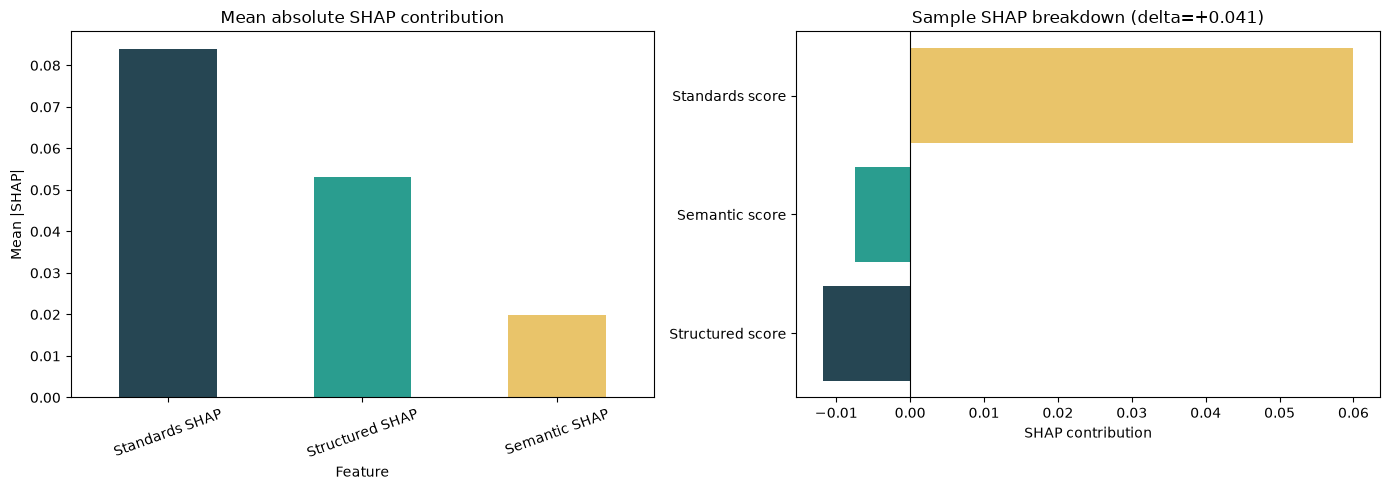

Saved SHAP visualization and sample report.


,rfp_id,sku_id,category,dominant_feature,explanation_text
0,RFP_0001,SKU_269,partially matching,Standards score,The pair is a partial match because the SHAP c...
1,RFP_0002,SKU_277,partially matching,Standards score,The pair is a partial match because the SHAP c...
2,RFP_0003,SKU_270,matching,Structured score,The pair is a strong match because the SHAP at...
3,RFP_0004,SKU_125,matching,Standards score,The pair is a strong match because the SHAP at...
4,RFP_0005,SKU_206,partially matching,Standards score,The pair is a partial match because the SHAP c...
5,RFP_0006,SKU_111,partially matching,Semantic score,The pair is a partial match because the SHAP c...
6,RFP_0007,SKU_246,partially matching,Standards score,The pair is a partial match because the SHAP c...
7,RFP_0008,SKU_257,matching,Standards score,The pair is a strong match because the SHAP at...
8,RFP_0009,SKU_163,matching,Standards score,The pair is a strong match because the SHAP at...
9,RFP_0010,SKU_233,matching,Standards score,The pair is a strong match because the SHAP at...


In [ ]:
import shap

SHAP_FEATURE_COLUMNS = ['Structured_Score', 'Semantic_Score', 'Standards_Score']
SHAP_DISPLAY_NAMES = {
    'Structured_Score': 'Structured score',
    'Semantic_Score': 'Semantic score',
    'Standards_Score': 'Standards score',
}
SHAP_WEIGHTS = np.array([0.5, 0.3, 0.2], dtype=float)

shap_feature_frame = match_df[SHAP_FEATURE_COLUMNS].astype(float).copy()
shap_baseline = shap_feature_frame.mean(axis=0)
shap_baseline_values = shap_baseline.to_numpy(dtype=float)
shap_expected_value = float(np.dot(shap_baseline_values, SHAP_WEIGHTS))


def score_to_category(final_score: float) -> str:
    if final_score >= 0.72:
        return 'matching'
    if final_score >= 0.42:
        return 'partially matching'
    return 'not matching'


def build_pair_explanation(row: pd.Series) -> Dict[str, Any]:
    rfp_id = row['RFP_ID']
    sku_id = row['SKU_ID']
    rfp_row = rfp_df.loc[rfp_df['rfp_id'] == rfp_id].iloc[0]
    sku_row = product_df.loc[product_df['sku_id'] == sku_id].iloc[0]

    structure = compare_structured_fields(rfp_row, sku_row)
    ground_truth_sku = rfp_row.get('ground_truth_sku')
    is_ground_truth = pd.notna(ground_truth_sku) and str(ground_truth_sku) == str(sku_id)
    top_ranked = bool(row.get('rank', 0) == 1)

    feature_values = np.array([
        float(row.get('Structured_Score', 0.0)),
        float(row.get('Semantic_Score', 0.0)),
        float(row.get('Standards_Score', 0.0)),
    ], dtype=float)
    shap_values = (feature_values - shap_baseline_values) * SHAP_WEIGHTS
    final_score = float(np.dot(feature_values, SHAP_WEIGHTS))
    category = score_to_category(final_score)
    score_gap = final_score - shap_expected_value

    feature_contributions = {
        SHAP_DISPLAY_NAMES[name]: float(value)
        for name, value in zip(SHAP_FEATURE_COLUMNS, shap_values)
    }
    dominant_index = int(np.argmax(np.abs(shap_values)))
    dominant_feature = SHAP_DISPLAY_NAMES[SHAP_FEATURE_COLUMNS[dominant_index]]
    dominant_direction = 'positive' if shap_values[dominant_index] >= 0 else 'negative'

    evidence = structure['evidence'][:]
    evidence.append(
        f"SHAP attributes {shap_values[dominant_index]:+.3f} to {dominant_feature}, relative to a baseline score of {shap_expected_value:.3f}."
    )
    evidence.append(
        f"Structured={feature_values[0]:.3f}, Semantic={feature_values[1]:.3f}, Standards={feature_values[2]:.3f}, Final={final_score:.3f}."
    )

    if category == 'matching':
        decision = 'The pair is a strong match because the SHAP attribution stays above the baseline and the positive contributions reinforce the final score.'
    elif category == 'partially matching':
        decision = 'The pair is a partial match because the SHAP contributions are mixed: some signals pull the score up while others hold it near the baseline.'
    else:
        decision = 'The pair is not a match because the SHAP contributions remain too weak to lift the final score above the matching range.'

    explanation_text = (
        f"{decision} Baseline={shap_expected_value:.3f}; "
        f"Structured SHAP={shap_values[0]:+.3f}, "
        f"Semantic SHAP={shap_values[1]:+.3f}, "
        f"Standards SHAP={shap_values[2]:+.3f}; "
        f"Final={final_score:.3f}."
    )

    rfp_name = rfp_row.get('item_name', rfp_row.get('rfp_name', ''))
    sku_name = sku_row.get('product_name', sku_row.get('sku_name', ''))

    reason_object = {
        'rfp_id': rfp_id,
        'sku_id': sku_id,
        'category': category,
        'is_ground_truth': bool(is_ground_truth),
        'top_ranked': top_ranked,
        'final_score': final_score,
        'baseline_score': shap_expected_value,
        'score_gap': score_gap,
        'structured_score': float(feature_values[0]),
        'semantic_score': float(feature_values[1]),
        'standards_score': float(feature_values[2]),
        'shap_structured': float(shap_values[0]),
        'shap_semantic': float(shap_values[1]),
        'shap_standards': float(shap_values[2]),
        'dominant_feature': dominant_feature,
        'dominant_direction': dominant_direction,
        'feature_contributions': feature_contributions,
        'evidence': evidence,
    }

    return {
        'rfp_id': rfp_id,
        'sku_id': sku_id,
        'rfp_name': rfp_name,
        'sku_name': sku_name,
        'ground_truth_sku': ground_truth_sku,
        'category': category,
        'is_ground_truth': bool(is_ground_truth),
        'top_ranked': top_ranked,
        'final_score': final_score,
        'structured_score': float(feature_values[0]),
        'semantic_score': float(feature_values[1]),
        'standards_score': float(feature_values[2]),
        'baseline_score': shap_expected_value,
        'shap_structured': float(shap_values[0]),
        'shap_semantic': float(shap_values[1]),
        'shap_standards': float(shap_values[2]),
        'score_gap': score_gap,
        'dominant_feature': dominant_feature,
        'explanation_text': explanation_text,
        'reason_object': reason_object,
    }


best_match_df = (
    match_df
    .sort_values(['RFP_ID', 'Final_Compliance_Score'], ascending=[True, False])
    .assign(rank=lambda frame: frame.groupby('RFP_ID').cumcount() + 1)
)

best_match_rows = best_match_df.groupby('RFP_ID', as_index=False).head(1).copy()
best_match_rows['rank'] = 1

explanation_rows = [build_pair_explanation(row) for _, row in best_match_rows.iterrows()]
explanation_df = pd.DataFrame(explanation_rows)
explanation_df['best_match_label'] = explanation_df['category']

explanation_df.to_csv(RESULTS_DIR / 'obj3_top1_explanations.csv', index=False)
explanation_df[
    [
        'rfp_id',
        'sku_id',
        'category',
        'final_score',
        'baseline_score',
        'structured_score',
        'semantic_score',
        'standards_score',
        'shap_structured',
        'shap_semantic',
        'shap_standards',
        'dominant_feature',
    ]
].to_csv(
    RESULTS_DIR / 'obj3_top1_summary.csv', index=False
)

print('Top-1 explanation rows:', explanation_df.shape)
display(explanation_df.head(10))

print('\nSaved reports:')
print(RESULTS_DIR / 'obj3_top1_explanations.csv')
print(RESULTS_DIR / 'obj3_top1_summary.csv')

mean_abs_shap = (
    explanation_df[['shap_structured', 'shap_semantic', 'shap_standards']]
    .abs()
    .mean()
    .rename(index={
        'shap_structured': 'Structured SHAP',
        'shap_semantic': 'Semantic SHAP',
        'shap_standards': 'Standards SHAP',
    })
    .sort_values(ascending=False)
)

sample_shap_row = explanation_df.iloc[0]
sample_shap_values = sample_shap_row[['shap_structured', 'shap_semantic', 'shap_standards']].to_numpy(dtype=float)
sample_shap_features = ['Structured score', 'Semantic score', 'Standards score']
sample_baseline_delta = float(sample_shap_row['final_score'] - sample_shap_row['baseline_score'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

mean_abs_shap.plot(kind='bar', ax=axes[0], color=['#264653', '#2a9d8f', '#e9c46a'])
axes[0].set_title('Mean absolute SHAP contribution')
axes[0].set_xlabel('Feature')
axes[0].set_ylabel('Mean |SHAP|')
axes[0].tick_params(axis='x', rotation=20)

axes[1].axvline(0.0, color='black', linewidth=0.8)
axes[1].barh(sample_shap_features, sample_shap_values, color=['#264653', '#2a9d8f', '#e9c46a'])
axes[1].set_title(f"Sample SHAP breakdown (delta={sample_baseline_delta:+.3f})")
axes[1].set_xlabel('SHAP contribution')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'obj3_shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

sample_report = explanation_df[
    ['rfp_id', 'sku_id', 'category', 'dominant_feature', 'explanation_text']
].head(10).copy()
sample_report.to_csv(RESULTS_DIR / 'obj3_sample_report.csv', index=False)
print('Saved SHAP visualization and sample report.')
display(sample_report)

## 8. Conclusions

OBJ1 provides the matching engine and the score decomposition. OBJ2 shows how the engine behaves under numeric, unit, completeness, long-document, and positional stress. OBJ3 turns both into an explanation layer that tells a reviewer why a pair matched, partially matched, or failed to match.

If Exp 3 or Exp 4 result CSVs are regenerated later, this notebook can load them automatically and extend the Obj2 summary without changing the core explainability logic.